# 06 — Experiments: a mini scaling law and attention visualizations

Two experiments that turn "I built a transformer" into "I *understand* transformers":

1. **A mini scaling law.** Train several model sizes under identical conditions and plot
   validation loss vs parameter count. We'll reproduce, on a laptop, the qualitative shape of the
   Kaplan/Chinchilla scaling curves that govern billion-dollar training runs.
2. **Attention maps.** Peek inside the trained model and *see* which tokens each head attends to.
   This is the visualization that makes attention concrete for an interviewer.

In [1]:
import sys, os, math, time, pickle
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
from model import GPT, GPTConfig

ROOT = Path("..").resolve()
device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available() else "cpu")
torch.manual_seed(1337)
print("device:", device)

# data (char-level Shakespeare, prepared in notebook 01/04)
dd = ROOT/"data"/"shakespeare_char"
train_data = np.memmap(dd/"train.bin", dtype=np.uint16, mode="r")
val_data   = np.memmap(dd/"val.bin",   dtype=np.uint16, mode="r")
meta = pickle.load(open(dd/"meta.pkl","rb"))

BLOCK, BATCH = 128, 32     # shorter context here so we can train several models quickly
def get_batch(split):
    d = train_data if split=="train" else val_data
    ix = torch.randint(len(d)-BLOCK-1, (BATCH,))
    x = torch.stack([torch.from_numpy(d[i:i+BLOCK].astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy(d[i+1:i+1+BLOCK].astype(np.int64)) for i in ix])
    return x.to(device), y.to(device)

device: mps


## Part 1 — A mini scaling law

**The claim (Kaplan et al. 2020, refined by Chinchilla 2022):** with enough data and compute,
a language model's loss falls as a smooth **power law** in the number of parameters —
`loss ≈ a·N^(-b) + c`. On a log-log plot, that power law is a straight line. Bigger models are
predictably better; the curve is how labs decide what to build before spending the compute.

We can't test billions of parameters on a laptop, but we can test the *shape*: train a handful of
sizes **under identical conditions** (same data, same steps, same LR schedule — only width/depth
changes) and see loss fall with N. Keeping everything else fixed is the whole point; otherwise we
couldn't attribute the improvement to size.

In [2]:
# a small helper training loop (same ingredients as notebook 04, condensed)
def train_model(cfg, iters=1200, lr_max=1e-3, lr_min=1e-4, warmup=100, log=False):
    model = GPT(cfg).to(device)
    decay = [p for p in model.parameters() if p.dim() >= 2]
    nodecay = [p for p in model.parameters() if p.dim() < 2]
    opt = torch.optim.AdamW([{"params":decay,"weight_decay":0.1},
                             {"params":nodecay,"weight_decay":0.0}], lr=lr_max, betas=(0.9,0.95))
    def lr_at(it):
        if it < warmup: return lr_max*(it+1)/warmup
        r = (it-warmup)/(iters-warmup); return lr_min+0.5*(1+math.cos(math.pi*r))*(lr_max-lr_min)
    model.train()
    for it in range(iters):
        for g in opt.param_groups: g["lr"] = lr_at(it)
        x,y = get_batch("train")
        _,loss = model(x,y)
        opt.zero_grad(set_to_none=True); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step()
    # final val loss, averaged over batches for a stable estimate
    model.eval()
    with torch.no_grad():
        vl = torch.stack([model(*get_batch("val"))[1] for _ in range(80)]).mean().item()
    return model, vl

In [3]:
# four sizes: only n_layer / n_head / n_embd change. Same everything else.
sizes = [
    dict(name="tiny",   n_layer=1, n_head=2, n_embd=64),
    dict(name="small",  n_layer=2, n_head=4, n_embd=128),
    dict(name="medium", n_layer=4, n_head=4, n_embd=192),
    dict(name="large",  n_layer=6, n_head=6, n_embd=288),
]
results = []
for s in sizes:
    cfg = GPTConfig(vocab_size=meta["vocab_size"], block_size=BLOCK,
                    n_layer=s["n_layer"], n_head=s["n_head"], n_embd=s["n_embd"], dropout=0.0)
    t0 = time.time()
    model, vl = train_model(cfg, iters=1200)
    n = model.num_params()
    results.append((s["name"], n, vl))
    print(f"{s['name']:7s} | {n/1e6:6.3f}M params | val loss {vl:.4f} | {time.time()-t0:4.0f}s")

tiny    |  0.054M params | val loss 2.3187 |    7s


small   |  0.402M params | val loss 1.9154 |   20s


medium  |  1.784M params | val loss 1.6886 |   62s


large   |  5.994M params | val loss 1.5811 |  173s


Now the plot. Two panels: linear axes to *see* the diminishing returns, and log-log axes where a
power law shows up as a straight line.

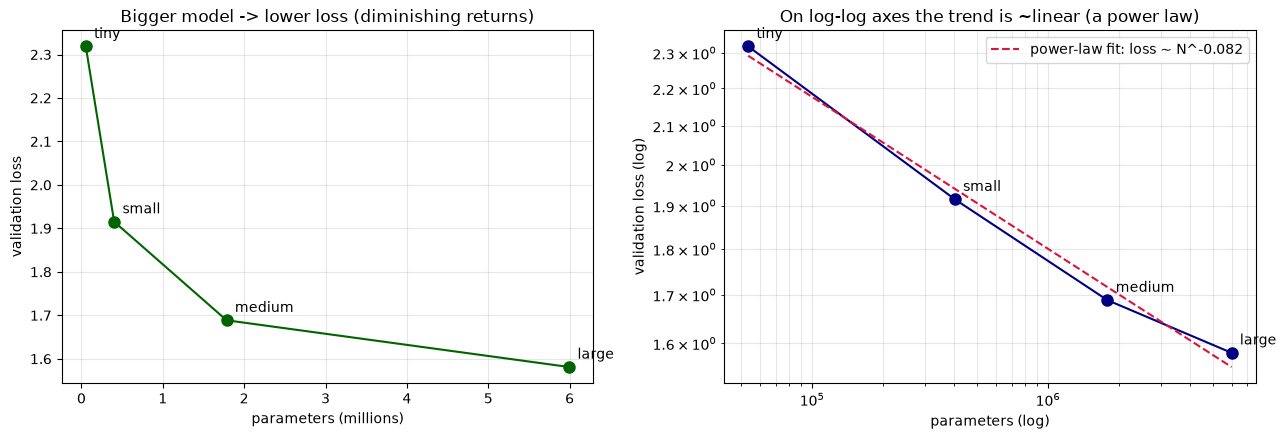

saved assets/scaling_law.png -- fitted exponent b = -0.082


In [4]:
names = [r[0] for r in results]
Ns    = np.array([r[1] for r in results], dtype=float)
losses= np.array([r[2] for r in results], dtype=float)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(Ns/1e6, losses, "o-", ms=8, color="darkgreen")
for name,n,l in results: ax[0].annotate(name, (n/1e6, l), textcoords="offset points", xytext=(6,6))
ax[0].set_xlabel("parameters (millions)"); ax[0].set_ylabel("validation loss")
ax[0].set_title("Bigger model -> lower loss (diminishing returns)"); ax[0].grid(alpha=0.3)

ax[1].loglog(Ns, losses, "o-", ms=8, color="navy")
# fit a power law loss = a * N^(-b) in log space to show the straight-line trend
b, loga = np.polyfit(np.log(Ns), np.log(losses), 1)
ax[1].loglog(Ns, np.exp(loga)*Ns**b, "--", color="crimson",
             label=f"power-law fit: loss ~ N^{b:.3f}")
for name,n,l in results: ax[1].annotate(name, (n, l), textcoords="offset points", xytext=(6,6))
ax[1].set_xlabel("parameters (log)"); ax[1].set_ylabel("validation loss (log)")
ax[1].set_title("On log-log axes the trend is ~linear (a power law)"); ax[1].legend(); ax[1].grid(alpha=0.3, which="both")
plt.tight_layout()
os.makedirs(ROOT/"assets", exist_ok=True); plt.savefig(ROOT/"assets"/"scaling_law.png", dpi=110, bbox_inches="tight")
plt.show()
print(f"saved assets/scaling_law.png -- fitted exponent b = {b:.3f}")

**What to take from this:** each jump in size buys a loss reduction, but a *shrinking* one — the
curve flattens. On the log-log axes the points fall near a straight line, i.e. an approximate
**power law**, the same qualitative law the big labs use to plan runs (they'd also scale *data*
and *compute* together — Chinchilla's refinement — which we hold fixed here). Our exponent won't
match theirs (we're wildly under-trained and under-data'd), but the **shape is real and it fell
out of a laptop in a few minutes**. That's the headline result of this experiment.

A caveat worth stating in an interview: with a fixed, small dataset and fixed steps, the largest
models here are the most *data-starved*, so the very last point may bend off the line. Real
scaling laws grow data and compute alongside parameters.

## Part 2 — Visualizing attention

Attention is not a black box — the weight matrix is right there. We enable the `record_attention`
hook we built into `CausalSelfAttention` (see [`model.py`](../model.py)), run a sentence through
the **trained hero model** from notebook 04, and plot each head's `(T, T)` weight matrix.

How to read the maps: **rows are queries** (the token doing the looking), **columns are keys**
(tokens being looked at). Cell (i, j) is how much token *i* attends to token *j*. Everything is
lower-triangular — the causal mask forbids looking right/forward. Bright = strong attention.

In [5]:
# load the trained hero model (block_size 256), produced by notebook 04
ckpt = torch.load(ROOT/"checkpoints"/"shakespeare_char.pt", map_location=device, weights_only=False)
hero = GPT(ckpt["config"]).to(device); hero.load_state_dict(ckpt["model"]); hero.eval()
stoi, itos = meta["stoi"], meta["itos"]

for blk in hero.blocks:                # turn on the recording hook in every block
    blk.attn.record_attention = True

sentence = "To be or not to be, that is the question."
ids = torch.tensor([[stoi[c] for c in sentence]], device=device)
with torch.no_grad():
    hero(ids)                          # a forward pass populates blk.attn.att_weights
print(f"captured attention for {len(hero.blocks)} layers x {hero.config.n_head} heads "
      f"on a {ids.shape[1]}-token sentence")

captured attention for 4 layers x 4 heads on a 41-token sentence


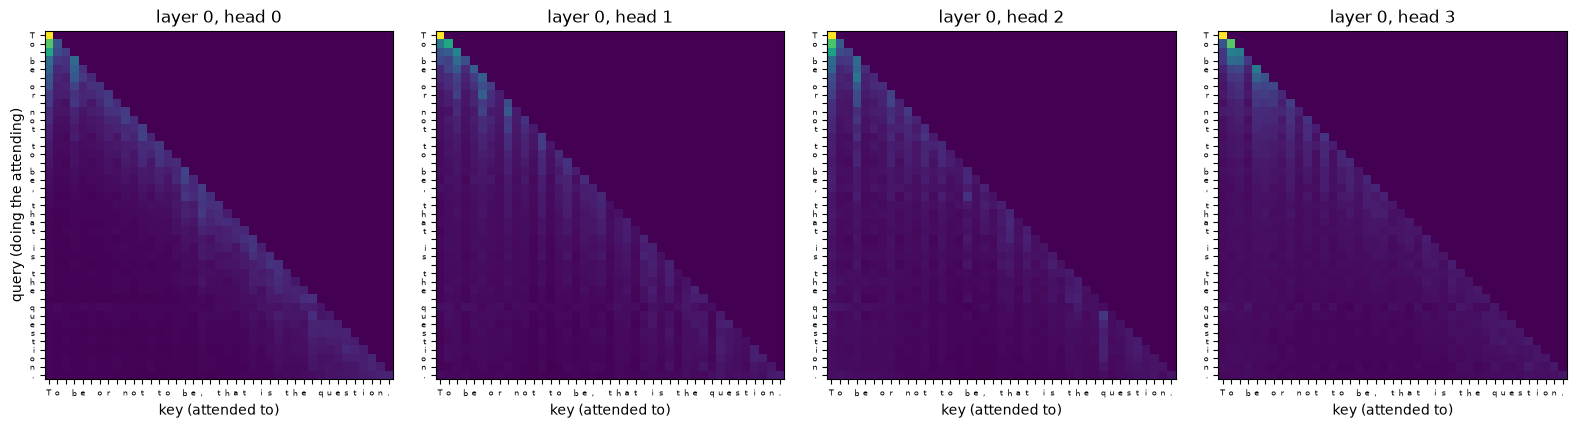

In [6]:
# plot all heads of a chosen layer
def plot_layer_heads(layer_idx, sentence, ids):
    att = hero.blocks[layer_idx].attn.att_weights[0]   # (n_head, T, T)
    T = ids.shape[1]; chars = list(sentence)
    nh = att.shape[0]
    fig, axes = plt.subplots(1, nh, figsize=(4*nh, 4))
    if nh == 1: axes = [axes]
    for h, ax in enumerate(axes):
        ax.imshow(att[h].cpu(), cmap="viridis", vmin=0)
        ax.set_title(f"layer {layer_idx}, head {h}")
        ax.set_xticks(range(T)); ax.set_xticklabels(chars, fontsize=6)
        ax.set_yticks(range(T)); ax.set_yticklabels(chars, fontsize=6)
        ax.set_xlabel("key (attended to)");
        if h==0: ax.set_ylabel("query (doing the attending)")
    plt.tight_layout(); return fig

fig = plot_layer_heads(0, sentence, ids)
plt.savefig(ROOT/"assets"/"attention_layer0.png", dpi=110, bbox_inches="tight"); plt.show()

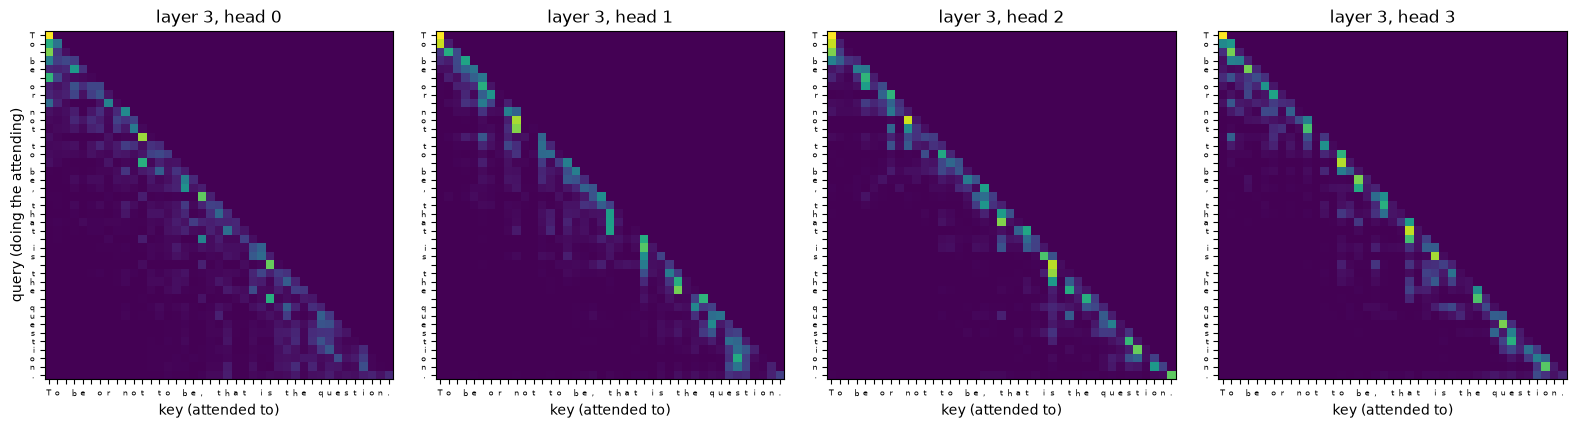

In [7]:
# the last layer often shows more structured, longer-range patterns
fig = plot_layer_heads(hero.config.n_layer - 1, sentence, ids)
plt.savefig(ROOT/"assets"/"attention_lastlayer.png", dpi=110, bbox_inches="tight"); plt.show()

### Reading the maps

Even in a tiny model, recognizable patterns emerge. Common ones to look for:

- **A bright diagonal / sub-diagonal** — the token attends to itself or the one just before it.
  These "previous-token" heads implement local n-gram-like copying, the bread and butter of a
  char model (predicting the next letter of a word from the last one or two).
- **A bright first column** — many queries attend back to the very first token. This is a
  well-documented "**attention sink**": a place for heads to dump weight when they have nothing
  specific to attend to (softmax must sum to 1, so the weight has to *go* somewhere).
- **Vertical stripes** at spaces or punctuation — heads that anchor on word/clause boundaries.

Let's quantify the previous-token pattern: for each head, what fraction of its attention mass
lands on the diagonal band (self + a few previous positions)? A high number means a local head.

In [8]:
def locality_scores(band=3):
    print(f"fraction of attention mass within {band} positions (local vs long-range):")
    for li, blk in enumerate(hero.blocks):
        att = blk.attn.att_weights[0]            # (nh, T, T)
        T = att.shape[-1]
        # boolean band: |i-j| < band
        i = torch.arange(T).view(-1,1); j = torch.arange(T).view(1,-1)
        near = ((i - j).abs() < band).float().to(att.device)
        frac = (att * near).sum(dim=(-1,-2)) / att.sum(dim=(-1,-2))
        print(f"  layer {li}: " + "  ".join(f"h{h}={frac[h]:.2f}" for h in range(att.shape[0])))

locality_scores()

fraction of attention mass within 3 positions (local vs long-range):
  layer 0: h0=0.41  h1=0.33  h2=0.31  h3=0.32
  layer 1: h0=0.30  h1=0.65  h2=0.63  h3=0.42
  layer 2: h0=0.56  h1=0.68  h2=0.73  h3=0.47
  layer 3: h0=0.50  h1=0.67  h2=0.74  h3=0.71


Heads with a high local fraction are doing short-range work; lower numbers mean a head reaches
further back. (Don't over-interpret a 0.8M-param char model — the point is the *method*: the
weights are fully inspectable, and this is exactly how interpretability researchers found
induction heads, name-mover heads, and so on in real models.)

## Takeaways

- **Scaling laws are real and reproducible in miniature.** Loss falls as an approximate power law
  in parameter count; on log-log axes it's ~linear, with diminishing returns. This is the
  empirical backbone of modern LLM planning — and it dropped out of a few minutes on a laptop.
- The comparison is only meaningful because **everything but size was held fixed** (data, steps,
  schedule). Changing multiple things at once would make the trend uninterpretable.
- **Attention is inspectable.** The `(T, T)` weight matrix per head shows exactly what each head
  looks at; we found previous-token heads, an attention-sink on the first token, and boundary
  heads — and measured head "locality" numerically.

**Interview quick-fire:**
- *What's a neural scaling law?* → test loss falls as a power law in parameters / data / compute; predictable enough to plan runs before doing them.
- *Chinchilla's correction to Kaplan?* → for a compute budget, scale *data and parameters together* (~20 tokens/param); Kaplan under-weighted data, giving under-trained big models.
- *What's an attention sink?* → a token (often the first) that heads dump leftover softmax mass on when nothing else is relevant.

**Next:** [07 — KV cache and modern upgrades](07_kv_cache_and_upgrades.ipynb): make generation
2–4× faster with a KV cache (measured), and compare RMSNorm / SwiGLU / RoPE against the baselines.